In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")

In [ ]:
# Load Excel dataset
df = pd.read_excel("SampleSuperstore.xlsx")

# Display first 5 rows
df.head()

In [3]:
# Check structure and data types
df.info()

# Statistical summary
df.describe()

# Column names
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [4]:
# Check missing values
df.isnull().sum()

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Clean text columns
df['Category'] = df['Category'].str.strip()
df['Sub-Category'] = df['Sub-Category'].str.strip()
df['Region'] = df['Region'].str.strip()
df['Segment'] = df['Segment'].str.strip()

# Convert numeric columns
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

# Fill missing values if any
df.fillna(0, inplace=True)

# Final cleaned dataset
df_clean = df.copy()

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64


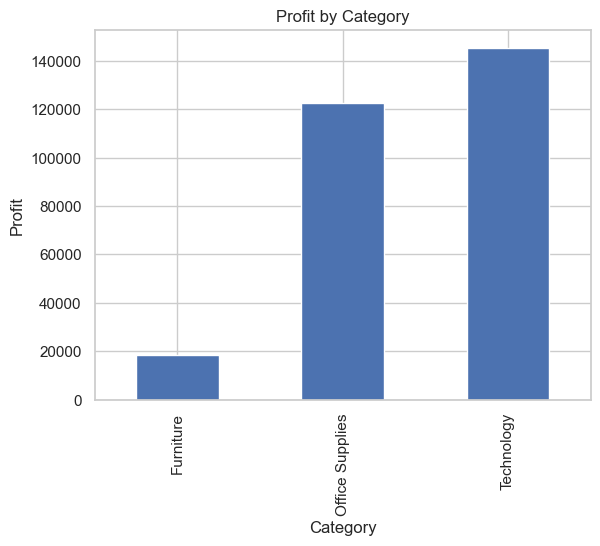

In [5]:
# Profit by Category
category_profit = df_clean.groupby('Category')['Profit'].sum().sort_values()

print(category_profit)

# Visualization
category_profit.plot(kind='bar', title="Profit by Category")
plt.ylabel("Profit")
plt.show()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5526.3820
Art             6524.6118
Envelopes       6964.1767
Furnishings    13052.7230
Appliances     18138.0054
Storage        21278.8264
Chairs         26567.1278
Binders        30228.0003
Paper          33944.2395
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


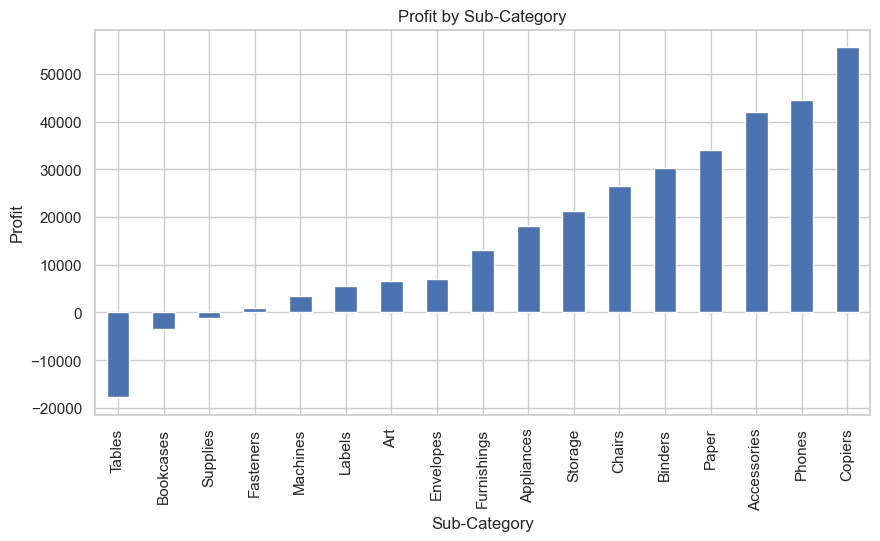

In [6]:
# Sub-category profit (worst to best)
subcat_profit = df_clean.groupby('Sub-Category')['Profit'].sum().sort_values()

print(subcat_profit)

# Visualization
subcat_profit.plot(kind='bar', figsize=(10,5), title="Profit by Sub-Category")
plt.ylabel("Profit")
plt.show()

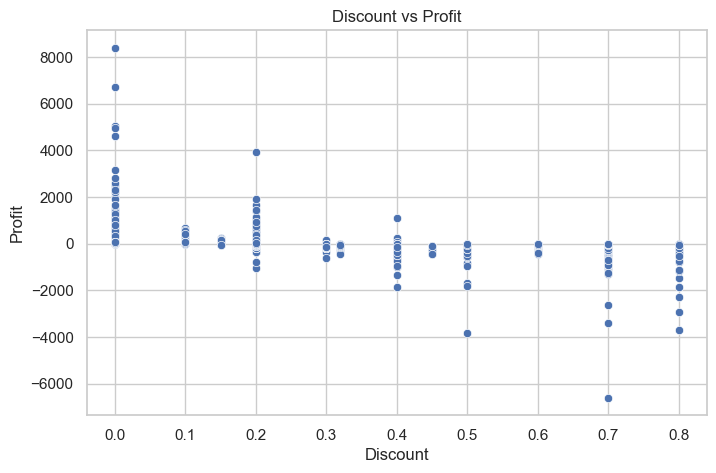

In [7]:
# Scatter plot: Discount vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df_clean)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Region
Central     39655.8752
South       46749.4303
East        91506.3092
West       108329.8079
Name: Profit, dtype: float64


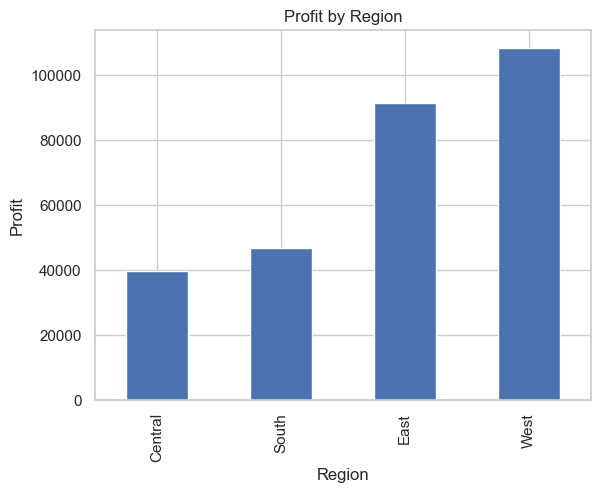

In [8]:
# Profit by Region
region_profit = df_clean.groupby('Region')['Profit'].sum().sort_values()

print(region_profit)

# Visualization
region_profit.plot(kind='bar', title="Profit by Region")
plt.ylabel("Profit")
plt.show()

Segment
Home Office     60279.0015
Corporate       91954.9798
Consumer       134007.4413
Name: Profit, dtype: float64


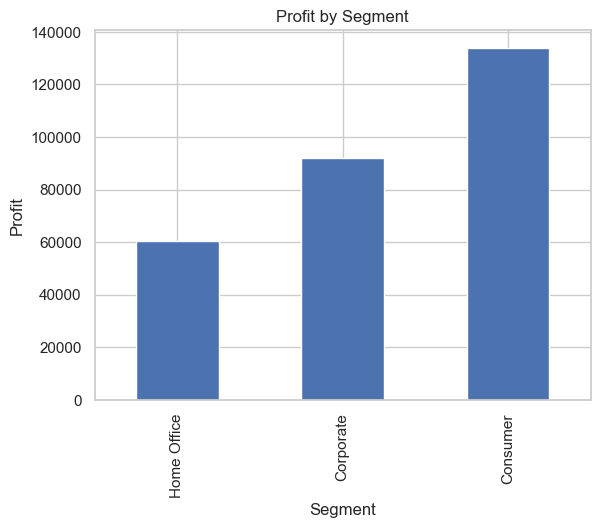

In [9]:
# Profit by Segment
segment_profit = df_clean.groupby('Segment')['Profit'].sum().sort_values()

print(segment_profit)

# Visualization
segment_profit.plot(kind='bar', title="Profit by Segment")
plt.ylabel("Profit")
plt.show()

In [10]:
# Identify worst and best categories
worst_category = df_clean.groupby('Category')['Profit'].sum().idxmin()
best_category = df_clean.groupby('Category')['Profit'].sum().idxmax()

# Identify worst sub-category
worst_subcat = df_clean.groupby('Sub-Category')['Profit'].sum().idxmin()

# Identify best region
best_region = df_clean.groupby('Region')['Profit'].sum().idxmax()
worst_region = df_clean.groupby('Region')['Profit'].sum().idxmin()

# Identify best segment
best_segment = df_clean.groupby('Segment')['Profit'].sum().idxmax()
worst_segment = df_clean.groupby('Segment')['Profit'].sum().idxmin()

print("===== KEY INSIGHTS =====\n")

print(f"1. The '{worst_category}' category shows the lowest profitability, indicating cost inefficiencies.")
print(f"2. The sub-category '{worst_subcat}' is the biggest loss contributor.")
print("3. Higher discounts are associated with lower profitability.")
print(f"4. The '{worst_region}' region underperforms compared to others.")
print(f"5. The '{best_region}' region contributes the highest profit.")
print(f"6. The '{worst_segment}' segment has the lowest profit.")
print(f"7. The '{best_segment}' segment is the most profitable.")

===== KEY INSIGHTS =====

1. The 'Furniture' category shows the lowest profitability, indicating cost inefficiencies.
2. The sub-category 'Tables' is the biggest loss contributor.
3. Higher discounts are associated with lower profitability.
4. The 'Central' region underperforms compared to others.
5. The 'West' region contributes the highest profit.
6. The 'Home Office' segment has the lowest profit.
7. The 'Consumer' segment is the most profitable.


In [11]:
print("\n===== RECOMMENDATIONS =====\n")

print("""
1. Reduce excessive discounts, especially on low-margin products.
2. Re-evaluate pricing strategy for loss-making sub-categories.
3. Improve or discontinue products with consistent losses.
4. Focus on high-performing regions to maximize profit.
5. Improve operational efficiency in underperforming regions.
6. Target high-profit customer segments for growth.
7. Optimize inventory and supply chain for better cost control.
""")


===== RECOMMENDATIONS =====


1. Reduce excessive discounts, especially on low-margin products.
2. Re-evaluate pricing strategy for loss-making sub-categories.
3. Improve or discontinue products with consistent losses.
4. Focus on high-performing regions to maximize profit.
5. Improve operational efficiency in underperforming regions.
6. Target high-profit customer segments for growth.
7. Optimize inventory and supply chain for better cost control.



Average Profit Margin by Category:
Category
Furniture          0.038679
Office Supplies    0.137735
Technology         0.156138
Name: Profit Margin, dtype: float64


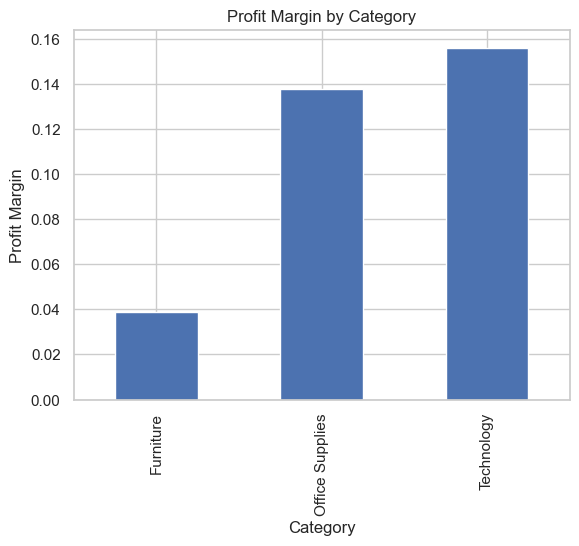

In [12]:
# Create Profit Margin KPI
df_clean['Profit Margin'] = df_clean['Profit'] / df_clean['Sales']

# Replace infinite/NaN values (if any)
df_clean.replace([np.inf, -np.inf], 0, inplace=True)
df_clean.fillna(0, inplace=True)

# Average Profit Margin by Category
kpi_category = df_clean.groupby('Category')['Profit Margin'].mean()

print("Average Profit Margin by Category:")
print(kpi_category)

# Visualization
kpi_category.plot(kind='bar', title="Profit Margin by Category")
plt.ylabel("Profit Margin")
plt.show()

Correlation Matrix:
                  Sales    Profit  Discount  Quantity  Profit Margin
Sales          1.000000  0.479067 -0.028311  0.200722       0.003595
Profit         0.479067  1.000000 -0.219662  0.066211       0.223981
Discount      -0.028311 -0.219662  1.000000  0.008678      -0.864384
Quantity       0.200722  0.066211  0.008678  1.000000      -0.005245
Profit Margin  0.003595  0.223981 -0.864384 -0.005245       1.000000


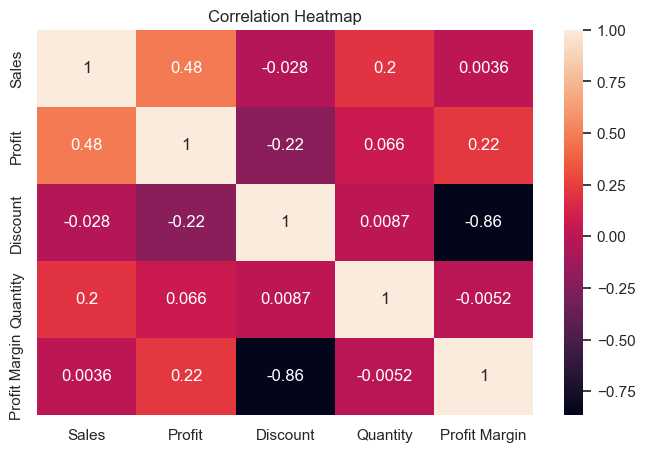

In [ ]:
# Correlation matrix
corr = df_clean[['Sales', 'Profit', 'Discount', 'Quantity', 'Profit Margin']].corr()

print("Correlation Matrix:")
print(corr)

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select features
X = df_clean[['Sales', 'Discount', 'Quantity']]
y = df_clean['Profit']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.17412221963848062
Mean Squared Error: 62932.162945682256


In [15]:
df_clean.to_excel("Cleaned_Superstore_Data.xlsx", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
